c:\Users\Nils\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


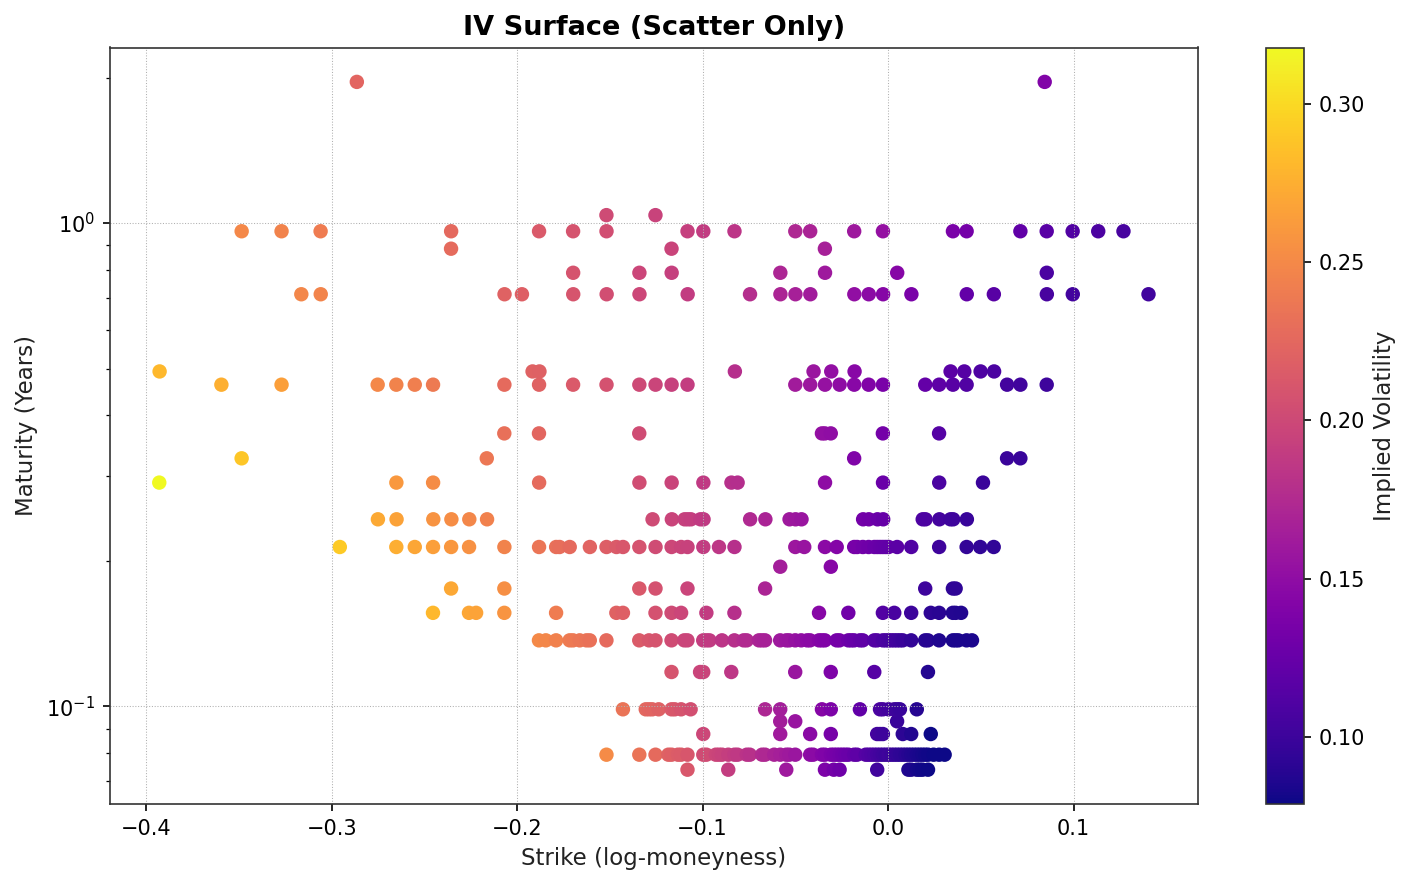

In [1]:
import pandas as pd
import numpy as np
import sys, os
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math



sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.utils import plot_iv_surface_scatter, preprocess_and_filter_otm, build_market_surfaces, prepare_df, plot_param_grid
from models.framework import DeepONet, MLP

df = pd.read_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/data_download.csv")
df = preprocess_and_filter_otm(df)
surfaces = build_market_surfaces(df)
plot_iv_surface_scatter(surfaces[0]["iv_surface"],surfaces[0]["grid"]["strikes"],np.exp(surfaces[0]["grid"]["maturities"]))

In [2]:
vol="rbergomi"

model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/deeponet.pth"
x = DeepONet.load(model_path)
deeponet_res = []
for surface in surfaces:
    res = x.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    deeponet_res.append(res)

Loaded DeepONet from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/rbergomi/deeponet.pth


In [3]:
model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/mlp.pth"
y = MLP.load(model_path)
mlp_res = []
for surface in surfaces:
    res = y.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    mlp_res.append(res)

Loaded MLP from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/rbergomi/mlp.pth


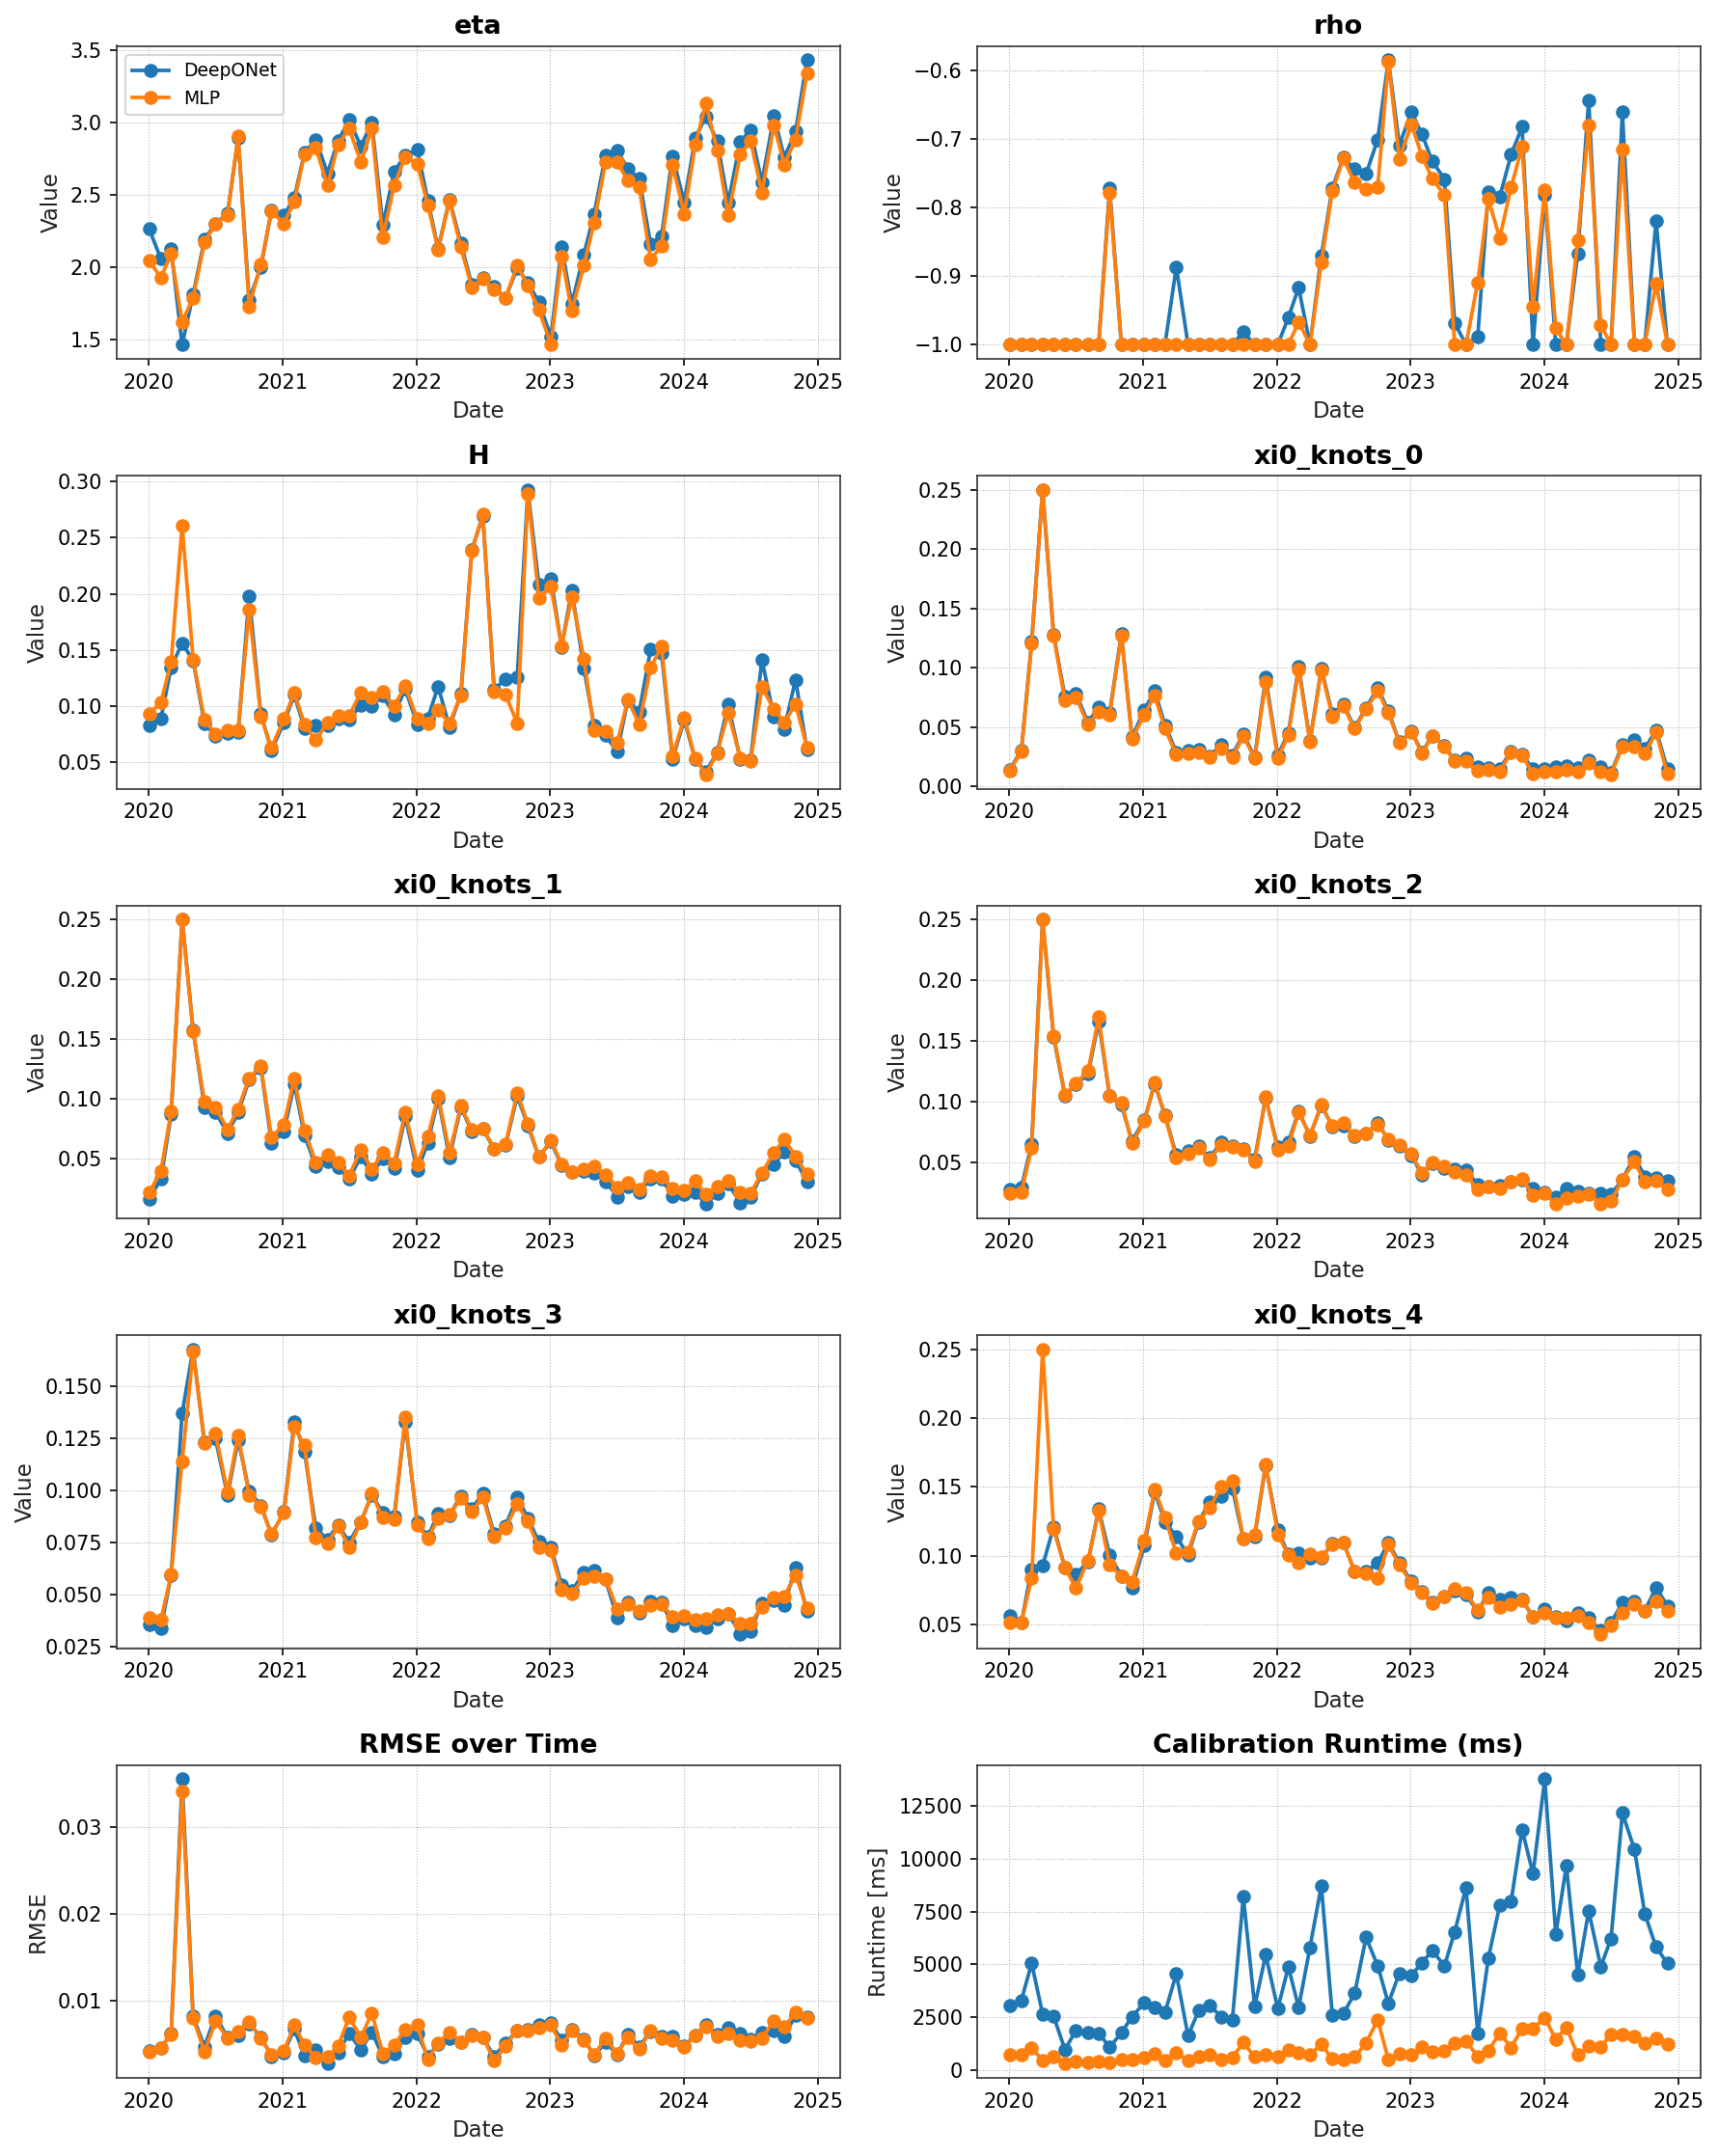


Average Calibration Runtime (ms):
model
DeepONet    4948.023283
MLP          976.393957
Name: runtime_ms, dtype: float64

Average RMSE:
model
DeepONet    0.006094
MLP         0.006200
Name: rmse, dtype: float64


In [4]:
plot_param_grid(deeponet_res, mlp_res, PARAM_NAMES=y.param_names)

## Validation of some results

In [6]:
len(deeponet_res)

60

RMSE:  0.014069772


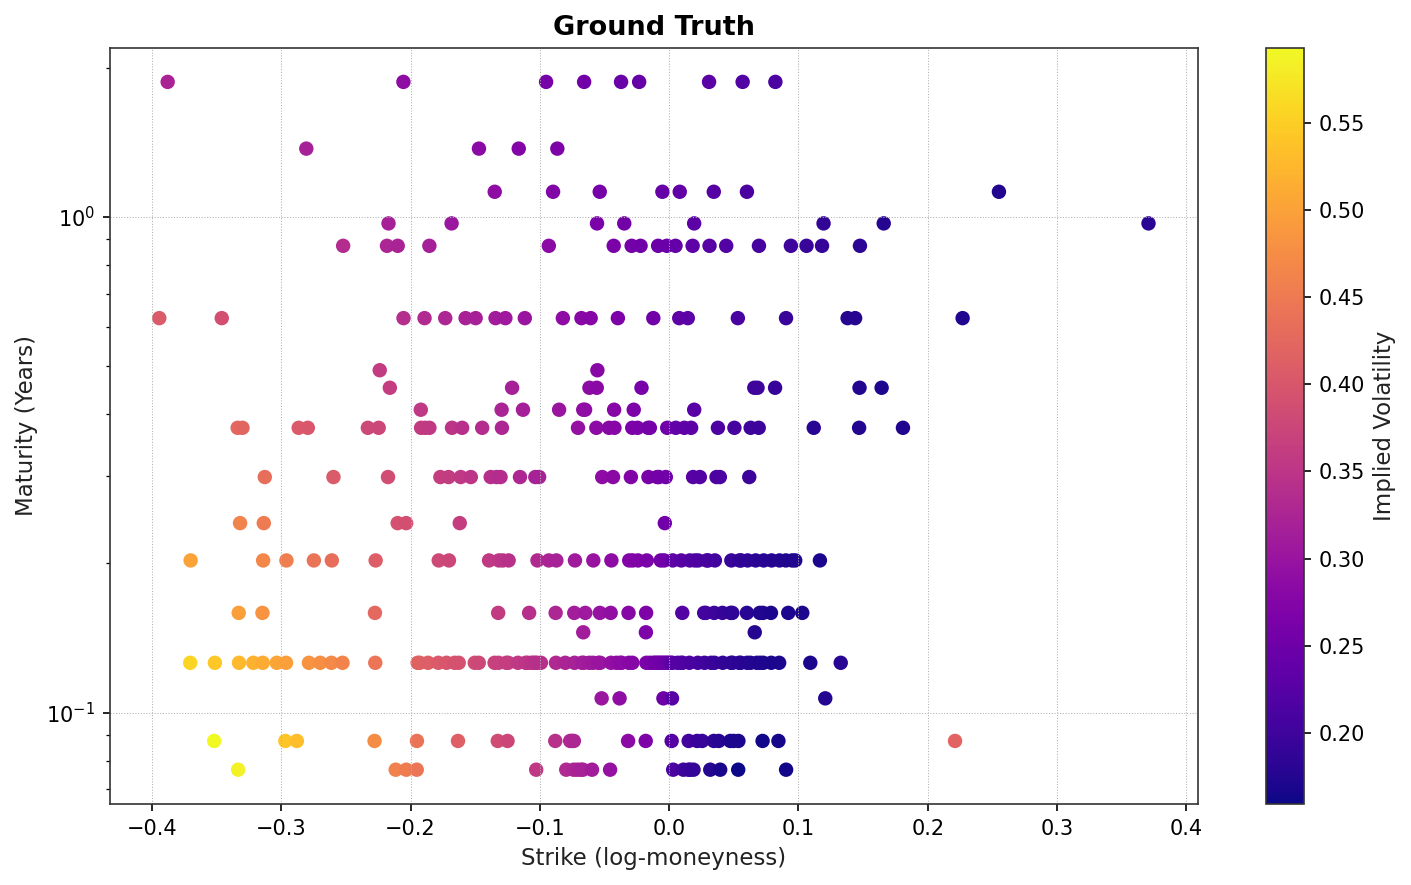

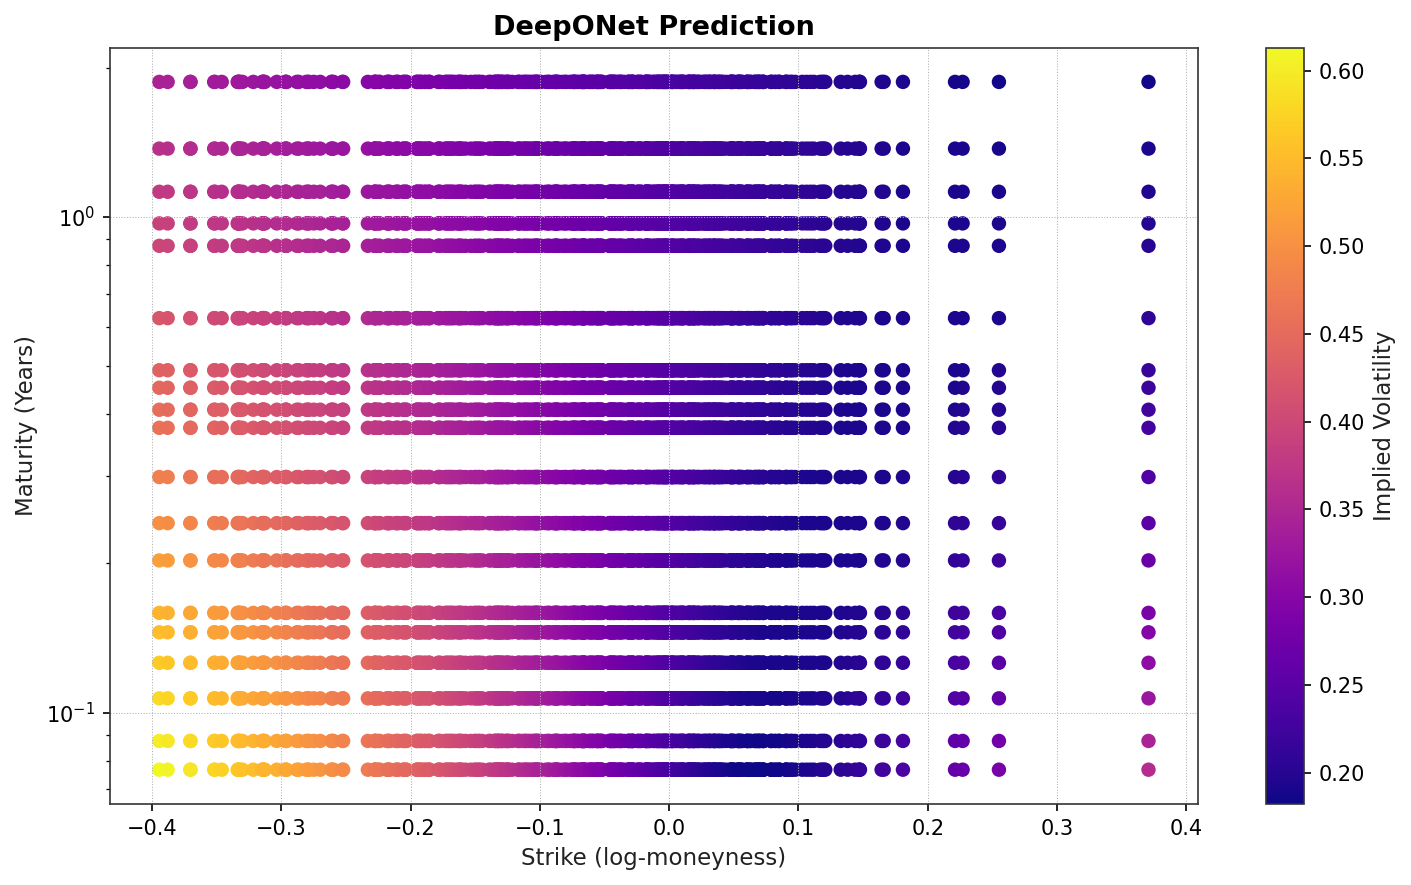

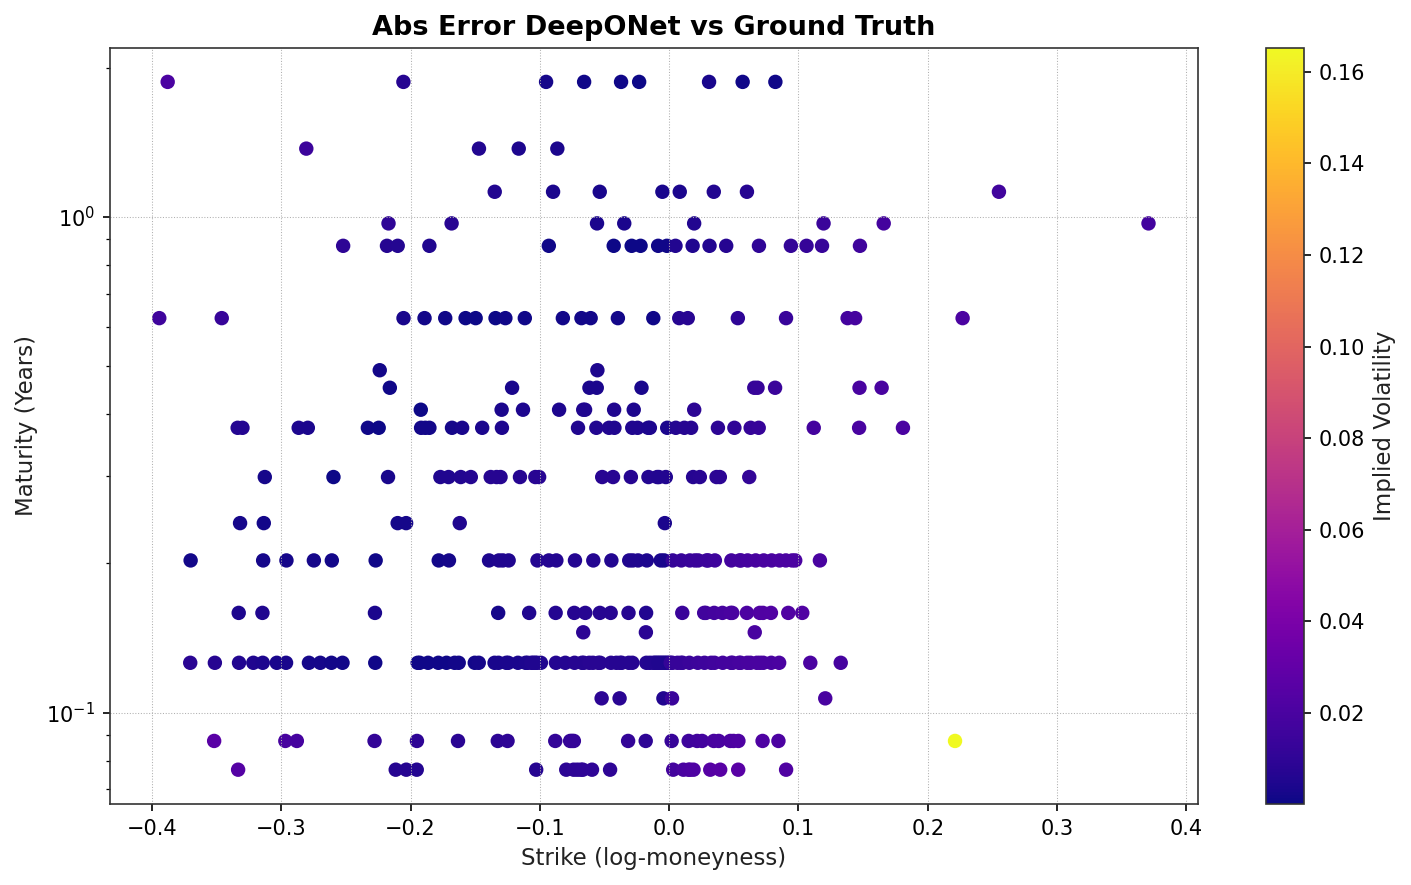

In [9]:
j = 13

p = deeponet_res[j]["theta_hat"]
params = {'eta':  p[0],
 'rho': p[1]+0.1,
 'H': p[2],
 'xi0_knots': p[3:]}

k = x.predict_surface(params, grid=surfaces[j]["grid"]).detach().numpy()
print("RMSE: ",np.sqrt(np.nanmean((k-surfaces[j]["iv_surface"])**2)))
plot_iv_surface_scatter(surfaces[j]["iv_surface"],surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Ground Truth")
plot_iv_surface_scatter(k,surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="DeepONet Prediction")
plot_iv_surface_scatter(np.abs(k-surfaces[j]["iv_surface"]),surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Abs Error DeepONet vs Ground Truth")